# Plot Spects for Match vs Mismatch Trials

For Load-3 models

- Plots for match vs mismatch (not caring about correct vs incorrect)
- Plots comparing match correct/incorrect, and mismatch correct/incorrect
    - append all of the trials together across models


In [1]:
import numpy as np 
from matplotlib import pyplot as plt 
import os
import sys
import importlib
import scipy.io
from collections import defaultdict

# import utils path
sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import spect_utils as su 
from bootstrap_method import *

## Load IPSCs, plot spects and band powers

## Now combine trials from all models

In [2]:
task_load = 3
n_neurons = 400
delay = 50

proj_dir = '/home/nuttidalab/Documents/spikeRNN/'
ipsc_dir = proj_dir + f'models/letters/load_{task_load}/IPSCs/'
model_dir = proj_dir + f'models/letters/load_{task_load}/'

# get all model IPSC files and model files
model_fnames = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f))]
print(f'Found {len(model_fnames)} model files')

Found 30 model files


### match vs mismatch

Note @Nuttida: don't run the following block — it's there for reference

In [3]:
# get correct and incorrect trials

importlib.reload(su)

s_match_all_exc = []
s_match_all_inh = []
s_mismatch_all_exc = []
s_mismatch_all_inh = []
perf_match_all = np.zeros(len(model_fnames))
perf_mismatch_all = np.zeros(len(model_fnames))
for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_nonorm_{model_fname}' # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = np.squeeze(model_ipsc['perf'])
    correct_idx = np.where(perf == 1)[0]
    labels = np.squeeze(model_ipsc['labels'])
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = np.squeeze(model_ipsc['probe_letters_all'])

    # get timing info
    settings = {
        'T': model_ipsc['T'][0][0],
        'delay': model_ipsc['delay'][0][0],
        'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
        'stim_dur': model_ipsc['stim_dur'][0][0],
        'probe_dur': model_ipsc['probe_dur'][0][0],
    }

    fs_rate = 200
    fs_ds = 1000

    T = int(settings['T']/fs_rate*fs_ds)
    stim_on = int(settings['stim_on']/fs_rate*fs_ds)
    stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
    probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
    response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

    # get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # spect params
    nperseg=25
    noverlap = nperseg//1.2
    nfft = nperseg*20

    # match & mismatch, all
    f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    
    s_match_all_exc.append(np.nanmean(s_match[exc_ind,:,:],axis=0))
    s_match_all_inh.append(np.nanmean(s_match[inh_ind,:,:],axis=0))
    s_mismatch_all_exc.append(np.nanmean(s_mismatch[exc_ind,:,:],axis=0))
    s_mismatch_all_inh.append(np.nanmean(s_mismatch[inh_ind,:,:],axis=0))

    perf_match_all[i] = np.mean(perf[labels == 1])
    perf_mismatch_all[i] = np.mean(perf[labels == -1])

s_match_all_exc = np.array(s_match_all_exc)
s_match_all_inh = np.array(s_match_all_inh)
s_mismatch_all_exc = np.array(s_mismatch_all_exc)
s_mismatch_all_inh = np.array(s_mismatch_all_inh)

print(s_match_all_exc.shape)
print(s_match_all_inh.shape)
print(s_mismatch_all_exc.shape)
print(s_mismatch_all_inh.shape)

print(f'Avg acc for match: {np.mean(perf_match_all)}')
print(f'Avg acc for mismatch: {np.mean(perf_mismatch_all)}')

Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_054931.mat (1/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_134828.mat (2/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_205654.mat (3/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_011120.mat (4/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_160950.mat (5/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_141900.mat (6/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_150729.mat (7/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_025720.mat (8/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_153608.mat (9/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_114448.mat (10/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_174646.mat (11/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12

In [4]:
np.save('s_match_all_exc.npy', s_match_all_exc)
np.save('s_match_all_inh.npy', s_match_all_inh)
np.save('s_mismatch_all_exc.npy', s_mismatch_all_exc)
np.save('s_mismatch_all_inh.npy', s_mismatch_all_inh)

np.save('f.npy', f)
np.save('t.npy', t)

In [ ]:
# run this @Nuttida

s_match_all_exc = np.load('s_match_all_exc.npy')
s_match_all_inh = np.load('s_match_all_inh.npy')
s_mismatch_all_exc = np.load('s_mismatch_all_exc.npy')
s_mismatch_all_inh = np.load('s_mismatch_all_inh.npy')

f = np.load('f.npy')
t = np.load('t.npy')

# get timing info
settings = {
    'T': model_ipsc['T'][0][0],
    'delay': model_ipsc['delay'][0][0],
    'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
    'stim_dur': model_ipsc['stim_dur'][0][0],
    'probe_dur': model_ipsc['probe_dur'][0][0],
}

fs_rate = 200
fs_ds = 1000

T = int(settings['T']/fs_rate*fs_ds)
stim_on = int(settings['stim_on']/fs_rate*fs_ds)
stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

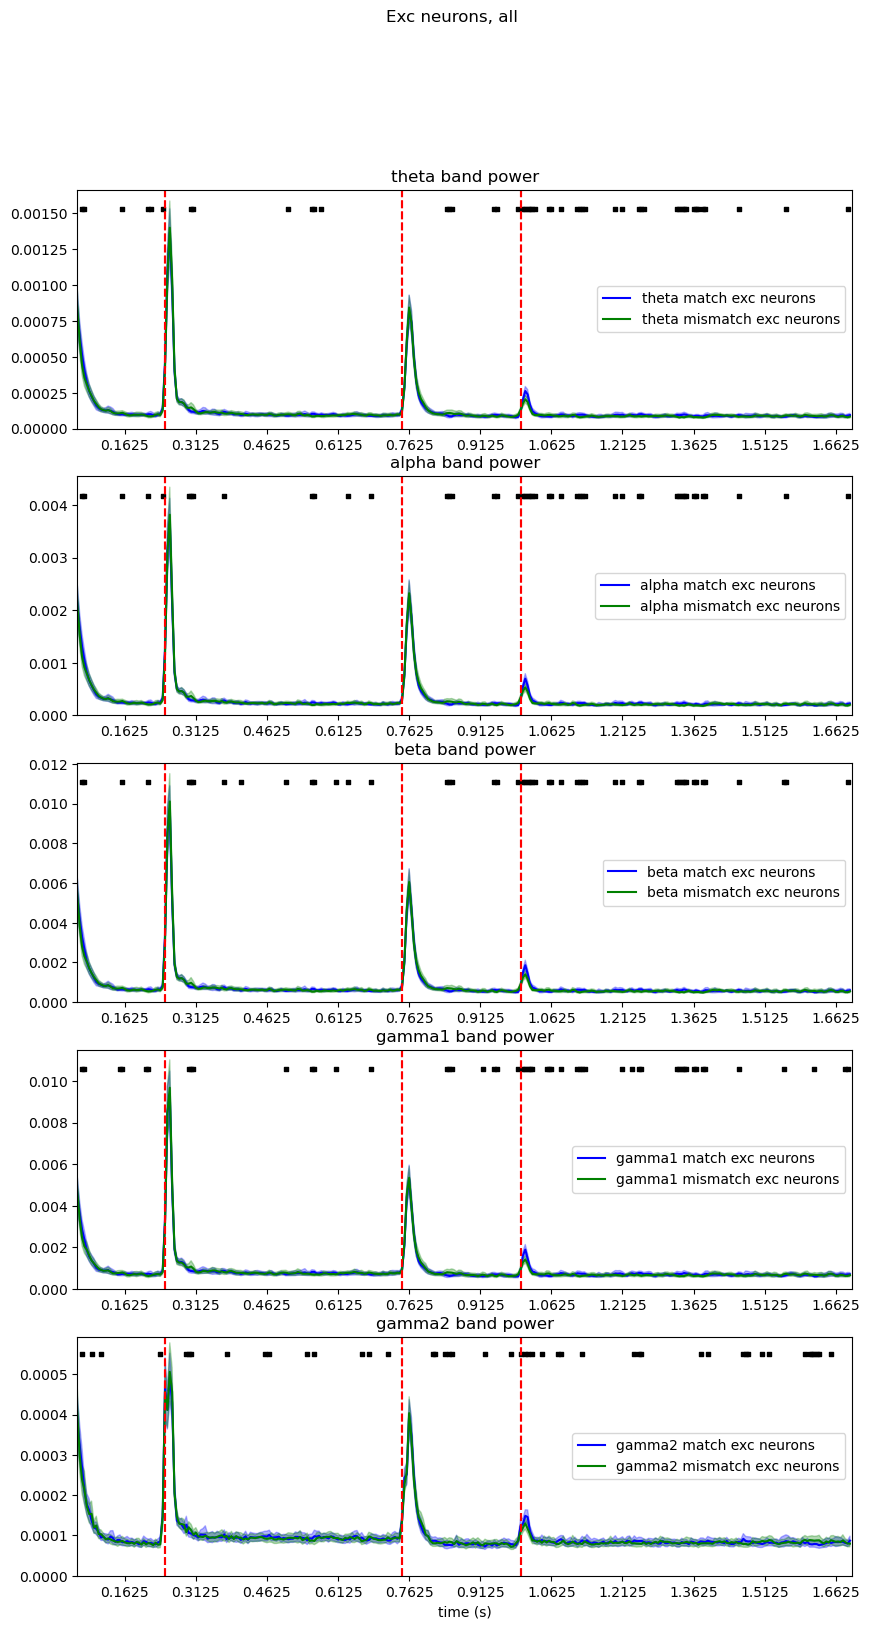

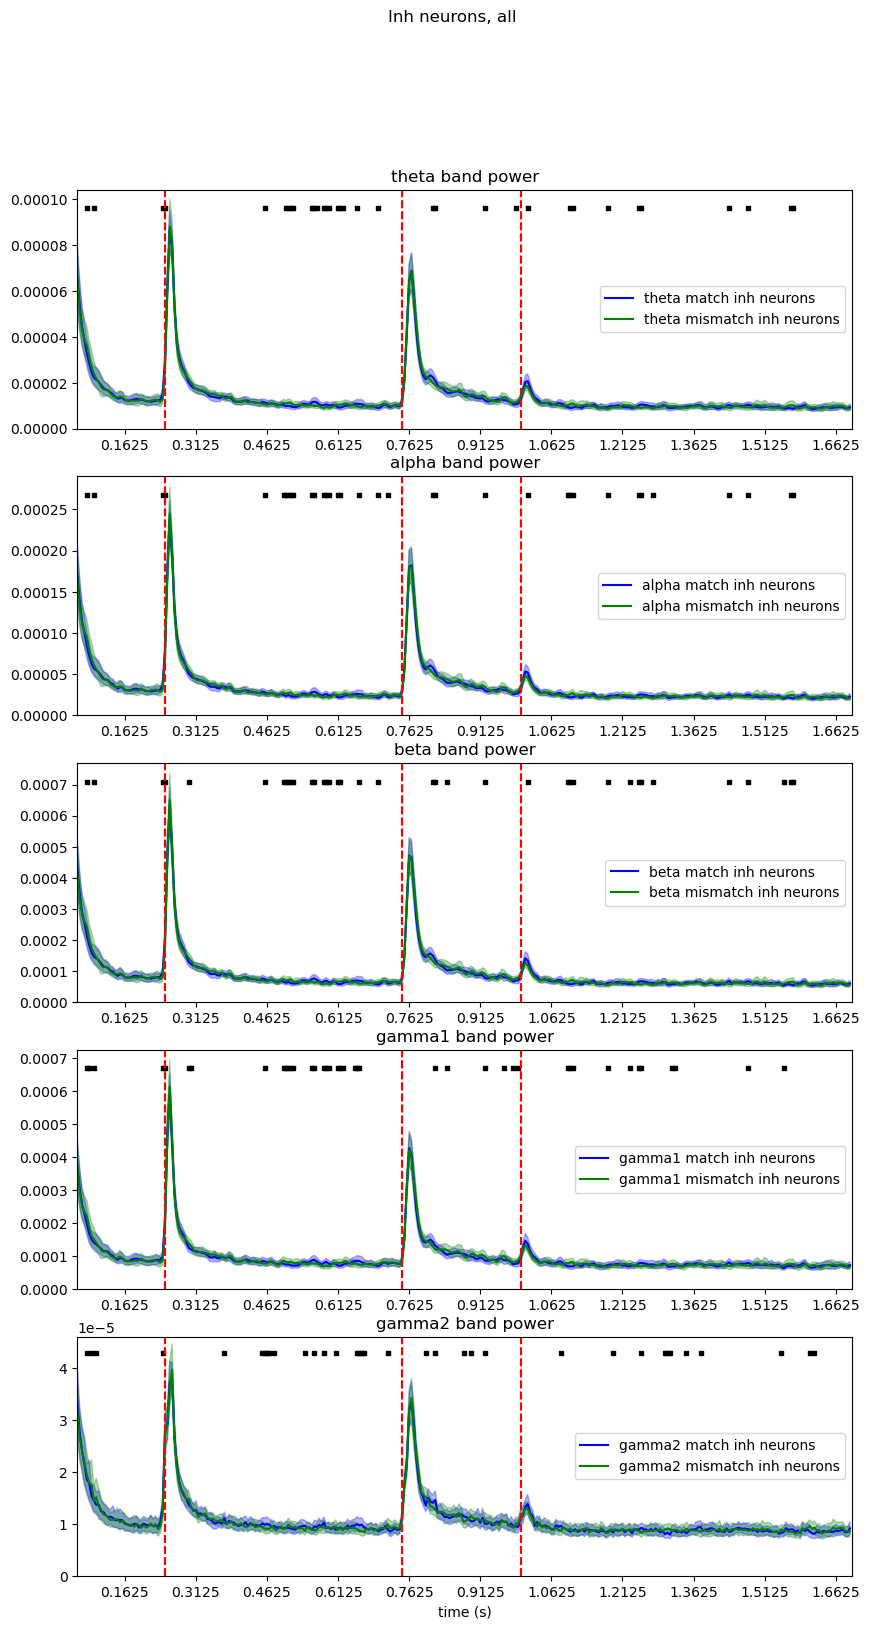

In [33]:
# get bootstrap confidence intervals
band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match_all_exc, s_mismatch_all_exc,
                stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                t_skip=30, f_skip=10, neur1_label='match exc neurons', neur2_label='mismatch exc neurons',
                nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Exc neurons, all',
                p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match_all_inh, s_mismatch_all_inh,
                stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                t_skip=30, f_skip=10, neur1_label='match inh neurons', neur2_label='mismatch inh neurons',
                nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Inh neurons, all',
                p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

### Split up also by correct vs incorrect

In [6]:
# get correct and incorrect trials

importlib.reload(su)

# Initialize dictionaries to hold the data for each condition
# spect_data = {}
spect_data = defaultdict(lambda: defaultdict(list))

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # Get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_nonorm_{model_fname}'  # no normalization
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    ipscs = model_ipsc['ipscs_all']
    
    fs_ds = 1000

    # Get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # Spect params
    nperseg = 25
    noverlap = nperseg // 1.2
    nfft = nperseg * 20

    neur_label = ['exc', 'inh']

    for j, match in enumerate([1, -1]):
        for k, corr in enumerate([1, 0]):
            for l, neur_idx in enumerate([exc_ind, inh_ind]):
                ipscs_neur = np.nanmean(ipscs[:,neur_idx,:], axis=1)
                f, t, s = su.calc_spect(ipscs_neur[(labels == match) & (perf == corr), :], fs_ds, nperseg, noverlap, nfft)
                del ipscs_neur

                if s.shape[0] == 0:
                    print(f"No data for match={match}, corr={corr}, neur = {neur_label[l]}")
                    continue  # Skip to the next iteration if no data is found
                
                bandpower, _ = su.calc_band_power(s, f, band='all')
                del s

                # Append the computed bandpower to the corresponding lists in the dictionary
                for key in bandpower:
                    spect_data[(match, corr, neur_label[l])][key].append(bandpower[key])
                del bandpower

# Now, we put all spects arrays into the same dictionary with the same keys as before
all_spects = {}

# For each condition (match, corr, exc/inh), stack the bandpower arrays for each key
for key in spect_data:
    all_spects[key] = {}
    for sub_key in spect_data[key]:
        all_spects[key][sub_key] = np.vstack(spect_data[key][sub_key])

# Print the shapes of the all_spects arrays for each key
for key, sub_dict in all_spects.items():
    for sub_key, arr in sub_dict.items():
        print(f"{key} -> {sub_key}: {arr.shape}")


Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_054931.mat (1/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_134828.mat (2/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_205654.mat (3/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_011120.mat (4/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_160950.mat (5/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_141900.mat (6/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_150729.mat (7/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_025720.mat (8/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_153608.mat (9/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_05_114448.mat (10/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_174646.mat (11/30)
Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12

In [7]:
np.save('all_spects.npy', all_spects)

In [ ]:
# run this @Nuttida
all_spects = np.load('all_spects.npy', allow_pickle=True).item()

In [19]:
# get timing info
settings = {
    'T': model_ipsc['T'][0][0],
    'delay': model_ipsc['delay'][0][0],
    'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
    'stim_dur': model_ipsc['stim_dur'][0][0],
    'probe_dur': model_ipsc['probe_dur'][0][0],
}

fs_rate = 200
fs_ds = 1000

T = int(settings['T']/fs_rate*fs_ds)
stim_on = int(settings['stim_on']/fs_rate*fs_ds)
stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

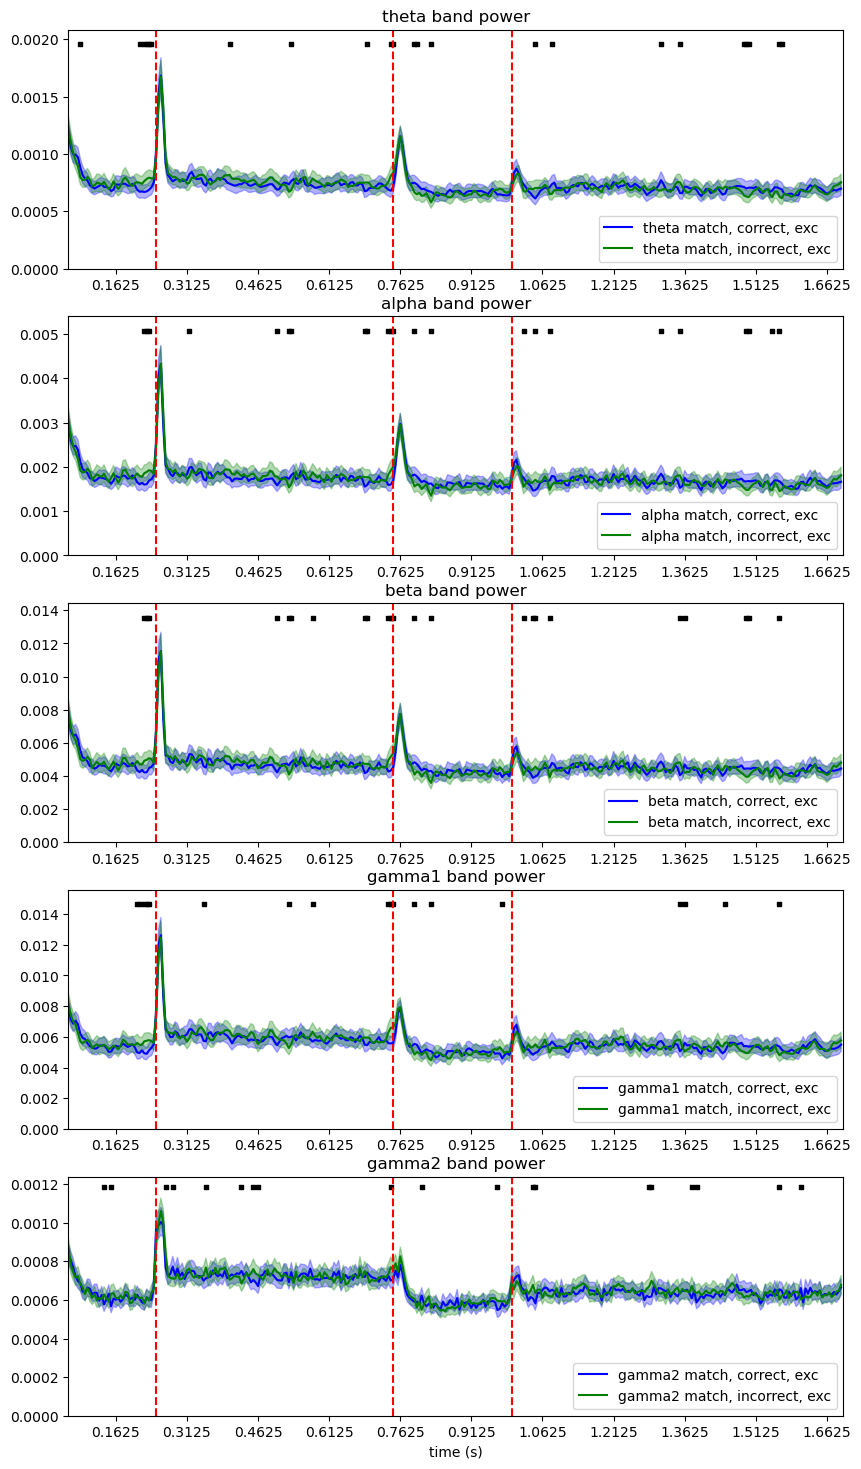

In [27]:
# (match, correct, exc) vs (match, incorrect, exc)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(1, 1, 'exc')], all_spects[(1, 0, 'exc')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='match, correct, exc', type2_label='match, incorrect, exc', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=30,
                              band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

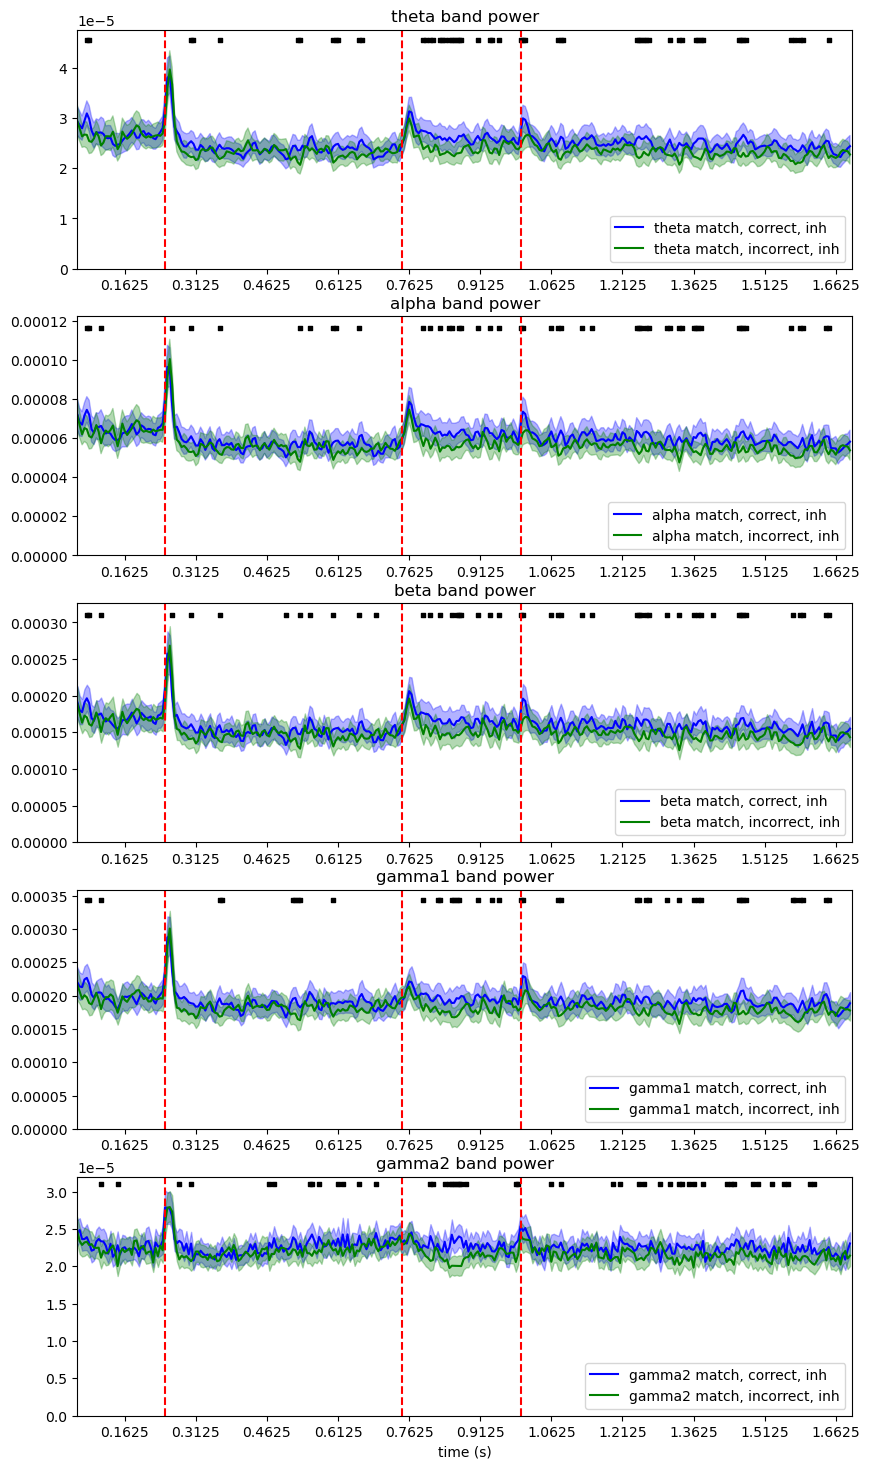

In [29]:
# (match, correct, inh) vs (match, incorrect, inh)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(1, 1, 'inh')], all_spects[(1, 0, 'inh')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='match, correct, inh', type2_label='match, incorrect, inh', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=30,
                              band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

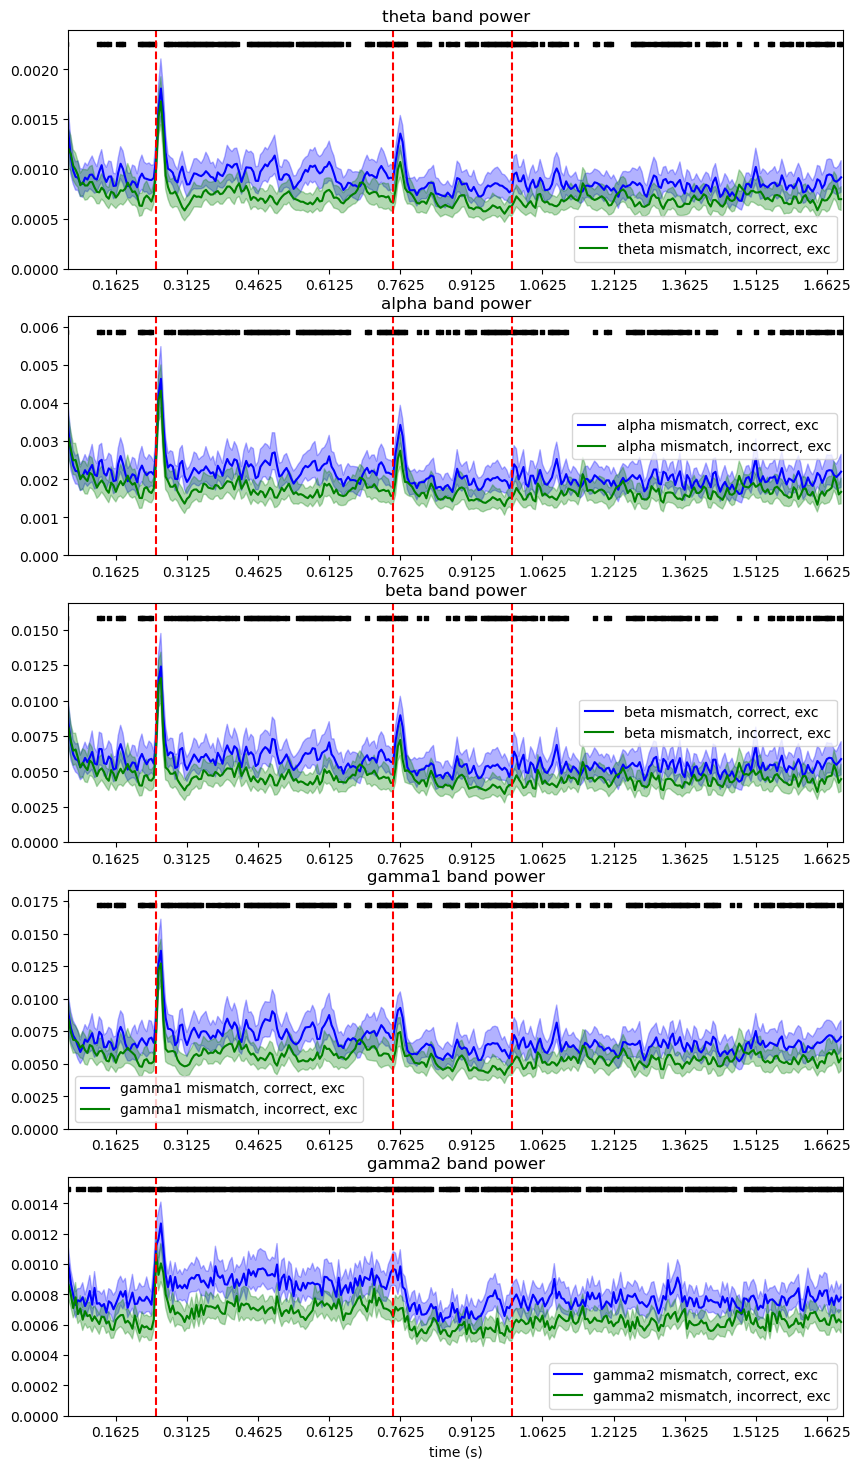

In [30]:
# (mismatch, correct, exc) vs (mismatch, incorrect, exc)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(-1, 1, 'exc')], all_spects[(-1, 0, 'exc')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='mismatch, correct, exc', type2_label='mismatch, incorrect, exc', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=30,
                              band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

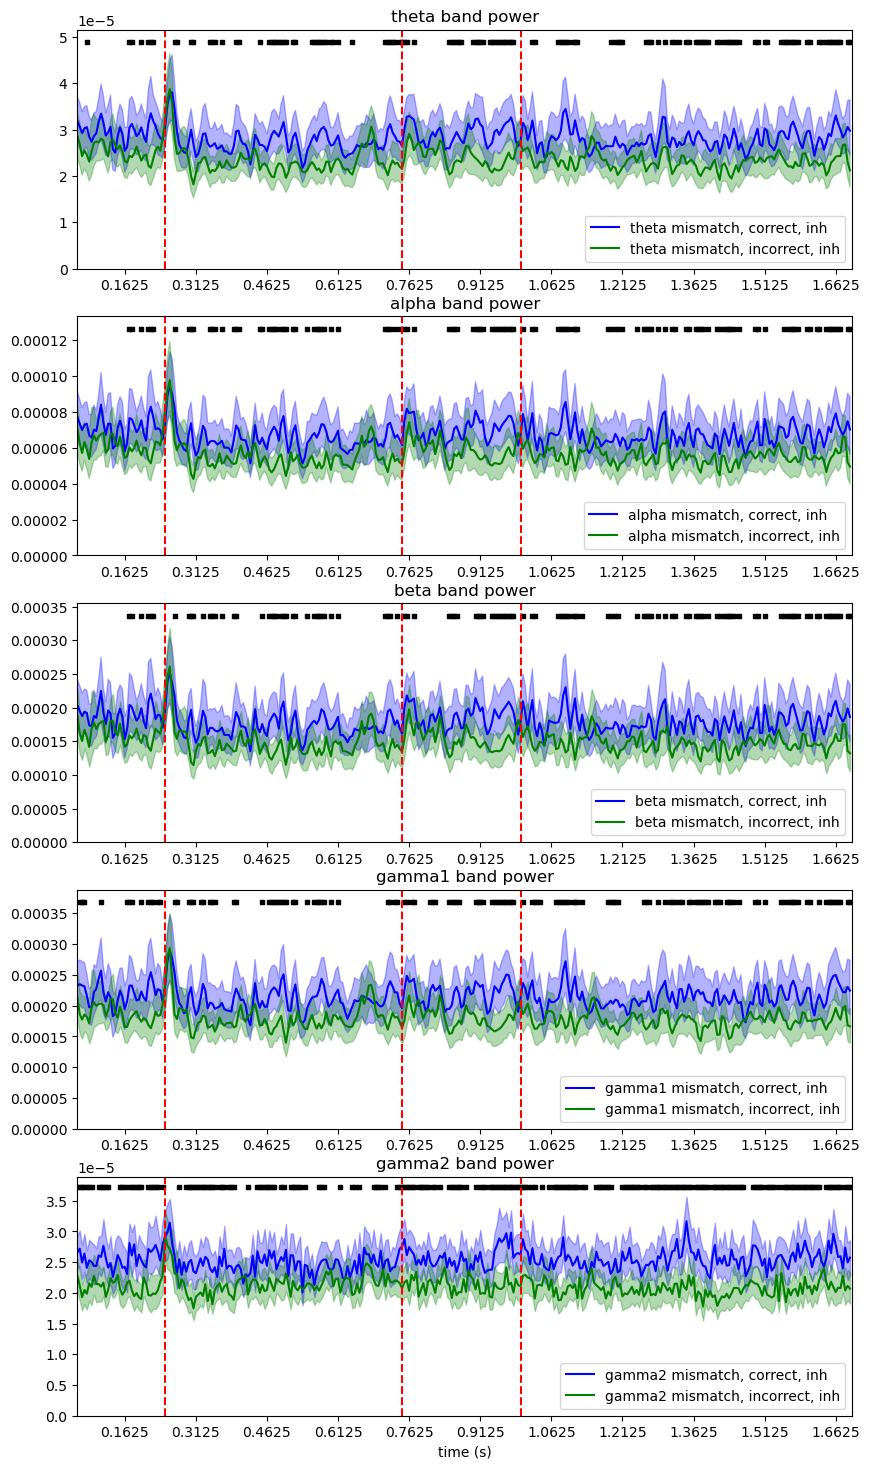

In [31]:
# (mismatch, correct, inh) vs (mismatch, incorrect, inh)
importlib.reload(su)
su.plot_band_power_bootstrap(all_spects[(-1, 1, 'inh')], all_spects[(-1, 0, 'inh')], t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                              type1_label='mismatch, correct, inh', type2_label='mismatch, incorrect, inh', p_sig=0.05, title = [],
                              stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, t_skip=30,
                              band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])